# CIE 457 — final project



1. Sets up a known true coefficient vector $\beta$ and a fixed design matrix $X$.
2. Repeatedly generates fresh data $y = X\beta + \varepsilon$ with Gaussian noise.
3. Computes $\hat\beta_{\text{OLS}} = (X^\top X)^{-1}X^\top y$ on each trial.
4. Compares the **empirical** distribution of $\hat\beta$ across trials to the **theoretical** $\mathcal{N}(\beta, \sigma^2(X^\top X)^{-1})$.

Run the cells in order from top to bottom.

## 1. Imports and reproducibility

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Fix the random seed so results are reproducible
RNG = np.random.default_rng(seed=42)

print("Setup complete.")

## 2. Setup: true parameters and design matrix

We choose the true $\beta$ and $\sigma$ ourselves so we can later check how close $\hat\beta$ gets. In a real problem we wouldn't know these.
$X$ is **fixed** across Monte Carlo trials — only the noise (and therefore $y$) changes from trial to trial.

In [ ]:
n = 100                                  # number of observations (people)
p = 3                                    # number of parameters: intercept + 2 features
beta_true = np.array([2.0, -1.5, 3.0])   # the unknown we pretend not to know
sigma_true = 1.5                         # noise standard deviation
sigma2_true = sigma_true ** 2            # sigma^2

# Build design matrix X with shape (n, p):
#   column 0: all 1's     -> intercept (so beta_0 is a baseline)
#   column 1: feature x1  -> uniform on [0, 5]
#   column 2: feature x2  -> uniform on [-2, 2]
intercept = np.ones(n)
x1 = RNG.uniform(0, 5, size=n)
x2 = RNG.uniform(-2, 2, size=n)
X = np.column_stack([intercept, x1, x2])

# Theoretical covariance of beta_hat: Cov(beta_hat) = sigma^2 (X^T X)^{-1}
XtX_inv = np.linalg.inv(X.T @ X)
theoretical_cov = sigma2_true * XtX_inv

print(f"Design matrix X shape: {X.shape}")
print(f"True beta:             {beta_true}")
print(f"Noise sigma:           {sigma_true}  (sigma^2 = {sigma2_true})")
print()
print("Theoretical Cov(beta_hat) = sigma^2 (X^T X)^(-1):")
print(np.round(theoretical_cov, 4))

Design matrix X shape: (100, 3)
True beta:             [ 2.  -1.5  3. ]
Noise sigma:           1.5  (sigma^2 = 2.25)

Theoretical Cov(beta_hat) = sigma^2 (X^T X)^(-1):
[[ 0.0958 -0.0301 -0.0049]
 [-0.0301  0.0124  0.002 ]
 [-0.0049  0.002   0.017 ]]


## 3. The OLS estimator

This function implements the formula derived in the report:
$$\hat\beta_{\text{OLS}} = (X^\top X)^{-1} X^\top y$$
We use `np.linalg.solve` for numerical stability — the math is identical.

In [ ]:
def ols_estimator(X, y):
    """OLS estimator: beta_hat = (X^T X)^{-1} X^T y"""
    return np.linalg.solve(X.T @ X, X.T @ y)


# Sanity check on a single trial before launching the Monte Carlo loop
eps_demo = RNG.normal(0.0, sigma_true, size=n)
y_demo = X @ beta_true + eps_demo
beta_demo = ols_estimator(X, y_demo)
print(f"True beta:          {beta_true}")
print(f"One-trial estimate: {np.round(beta_demo, 4)}")
print("(Close but not identical — that's the random variability we'll study.)")

## 4. Monte Carlo simulation

Each trial: draw fresh $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$, form $y = X\beta + \varepsilon$, compute $\hat\beta$, store it.
After many trials we look at the **empirical** distribution of $\hat\beta$.

In [ ]:
n_trials = 10_000
beta_hats = np.zeros((n_trials, p))      # storage for all the beta_hat samples

for trial in range(n_trials):
    eps = RNG.normal(loc=0.0, scale=sigma_true, size=n)   # homoscedastic Gaussian noise
    y = X @ beta_true + eps                                # generate fresh data
    beta_hats[trial] = ols_estimator(X, y)                 # estimate

print(f"Done. Stored {n_trials} beta_hat estimates.")

Done. Stored 10000 beta_hat estimates.


## 5. Empirical vs theoretical: numerical comparison

If the theory is right, then:
- The empirical mean of $\hat\beta$ across trials should be close to the true $\beta$ (unbiasedness).
- The empirical covariance should be close to $\sigma^2(X^\top X)^{-1}$.

In [ ]:
empirical_mean = beta_hats.mean(axis=0)
empirical_cov = np.cov(beta_hats, rowvar=False)

print("=" * 70)
print("   HOMOSCEDASTIC MONTE CARLO RESULTS")
print("=" * 70)
print(f"   Number of trials : {n_trials}")
print(f"   Sample size n    : {n}")
print(f"   Parameters p     : {p}")
print(f"   sigma^2 (true)   : {sigma2_true}")
print()
print(f"   True beta             : {beta_true}")
print(f"   Empirical mean beta_hat: {np.round(empirical_mean, 4)}")
print(f"   |bias|                 : {np.round(np.abs(empirical_mean - beta_true), 4)}")
print()
print("   Theoretical Cov(beta_hat) = sigma^2 (X^T X)^{-1}:")
print(np.round(theoretical_cov, 4))
print()
print("   Empirical Cov(beta_hat):")
print(np.round(empirical_cov, 4))
print()
print(f"   Max abs difference: {np.max(np.abs(empirical_cov - theoretical_cov)):.5f}")
print("=" * 70)

   HOMOSCEDASTIC MONTE CARLO RESULTS
   Number of trials : 10000
   Sample size n    : 100
   Parameters p     : 3
   sigma^2 (true)   : 2.25

   True beta             : [ 2.  -1.5  3. ]
   Empirical mean beta_hat: [ 1.9969 -1.4987  3.0015]
   |bias|                 : [0.0031 0.0013 0.0015]

   Theoretical Cov(beta_hat) = sigma^2 (X^T X)^{-1}:
[[ 0.0958 -0.0301 -0.0049]
 [-0.0301  0.0124  0.002 ]
 [-0.0049  0.002   0.017 ]]

   Empirical Cov(beta_hat):
[[ 0.0959 -0.0301 -0.0042]
 [-0.0301  0.0123  0.0017]
 [-0.0042  0.0017  0.0168]]

   Max abs difference: 0.00070


## 6. Plot 1 — Marginal distributions

For each component $\hat\beta_j$, the empirical histogram (purple) should match the theoretical Gaussian density (orange) centered on the true value.

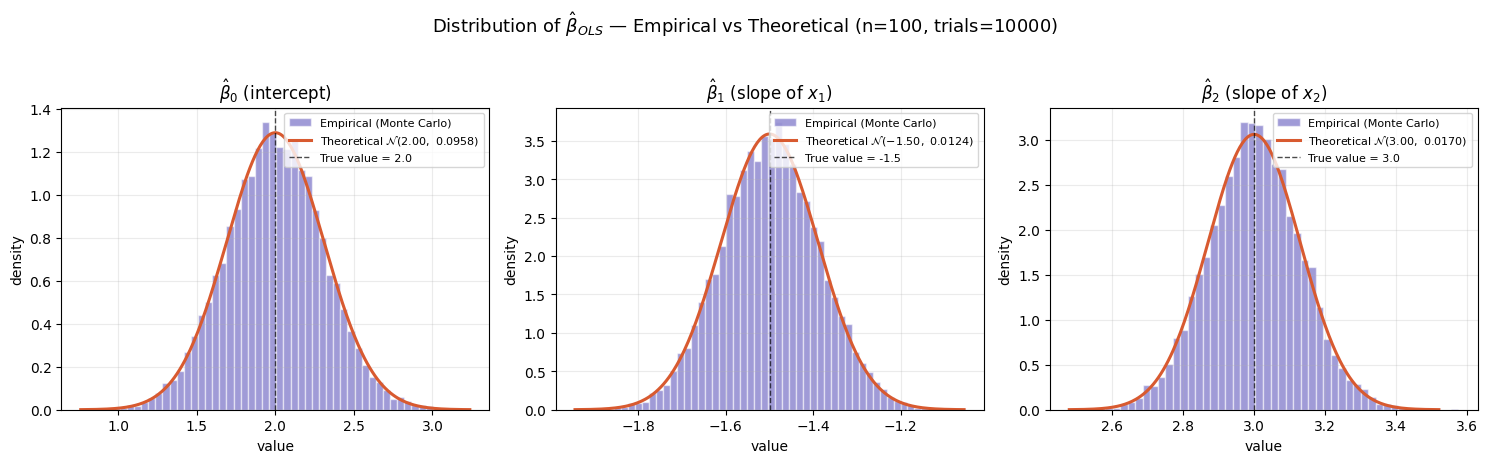

In [ ]:
fig, axes = plt.subplots(1, p, figsize=(15, 4.5))
component_names = [r'$\hat\beta_0$ (intercept)',
                   r'$\hat\beta_1$ (slope of $x_1$)',
                   r'$\hat\beta_2$ (slope of $x_2$)']

for j, ax in enumerate(axes):
    ax.hist(beta_hats[:, j], bins=50, density=True,
            color='#534AB7', alpha=0.55, edgecolor='white',
            label='Empirical (Monte Carlo)')
    mu = beta_true[j]
    sd = np.sqrt(theoretical_cov[j, j])
    grid = np.linspace(mu - 4 * sd, mu + 4 * sd, 300)
    ax.plot(grid, stats.norm.pdf(grid, loc=mu, scale=sd),
            color='#D85A30', linewidth=2.2,
            label=fr'Theoretical $\mathcal{{N}}({mu:.2f},\ {sd**2:.4f})$')
    ax.axvline(mu, color='black', linestyle='--', linewidth=1, alpha=0.7,
               label=f'True value = {mu}')
    ax.set_title(component_names[j], fontsize=12)
    ax.set_xlabel('value'); ax.set_ylabel('density')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.25)

plt.suptitle(r'Distribution of $\hat\beta_{OLS}$ — Empirical vs Theoretical '
             f'(n={n}, trials={n_trials})', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 7. Plot 2 — Joint distribution

The cloud is centered on the true point and the elliptical tilt comes from the **off-diagonal** entry of $(X^\top X)^{-1}$, meaning $\hat\beta_1$ and $\hat\beta_2$ are correlated as estimators.

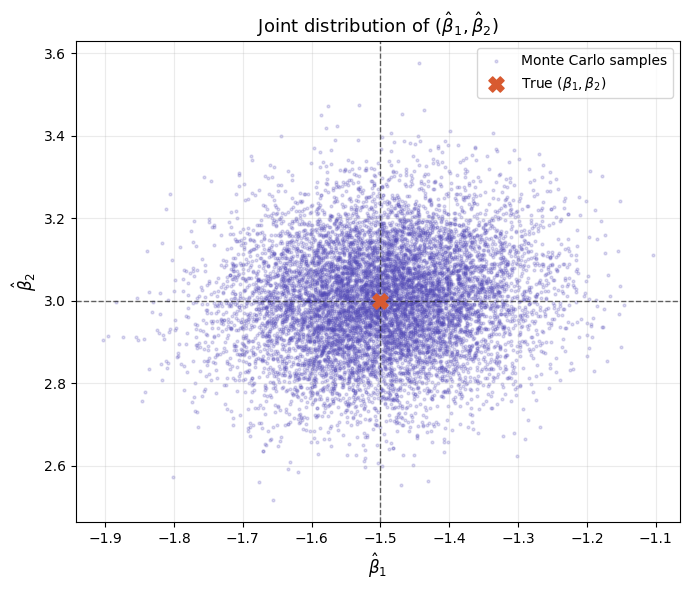

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(beta_hats[:, 1], beta_hats[:, 2],
           s=4, alpha=0.20, color='#534AB7', label='Monte Carlo samples')
ax.axvline(beta_true[1], color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(beta_true[2], color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.scatter([beta_true[1]], [beta_true[2]], color='#D85A30', s=120,
           marker='X', label=fr'True $(\beta_1,\beta_2)$', zorder=5)
ax.set_xlabel(r'$\hat\beta_1$', fontsize=12)
ax.set_ylabel(r'$\hat\beta_2$', fontsize=12)
ax.set_title(r'Joint distribution of $(\hat\beta_1, \hat\beta_2)$', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## What to expect

After running everything you should see:
- Empirical mean of $\hat\beta$ matches the true $\beta$ to ~3 decimal places (unbiasedness verified ✓)
- Empirical covariance matches $\sigma^2(X^\top X)^{-1}$ within sampling noise (~10⁻⁴) ✓
- Histograms hug the theoretical Gaussian curves ✓
- Joint scatter forms a tilted elliptical cloud centered on the truth ✓

Together these confirm:
$$\hat\beta_{\text{OLS}} \sim \mathcal{N}\bigl(\beta,\ \sigma^2(X^\top X)^{-1}\bigr)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
import pandas as pd

def ols_estimator(x,y):
  return np.linalg.inv(x.T@x)@x.T@y


def estimate_sigma2(x,y,beta_hat):
  n, p=x.shape
  residuals=y-x@beta_hat
  return (residuals.T@residuals)/(n-p)

## Confidence Interval for Regression Coefficients

This function computes confidence intervals for each coefficient.

The confidence interval is given by:

$\hat{\beta}_i \pm t_{\alpha/2, n-p} \cdot \text{SE}(\hat{\beta}_i)$

where the standard error is:

$\text{SE}(\hat{\beta}_i) = \sqrt{\hat{\sigma}^2 (X^T X)^{-1}_{ii}}$

The covariance matrix of the OLS estimator is:

$\text{Cov}(\hat{\beta}) = \sigma^2 (X^T X)^{-1}$

Confidence intervals quantify uncertainty in the estimated regression coefficients.

In [ ]:
def confidance_interval(x,y,alpha=0.05):
  n,p=x.shape
  beta_hat=ols_estimator(x,y)
  sigma2_hat=estimate_sigma2(x,y,beta_hat)

  xtx_inv=np.linalg.inv(x.T@x)
  se=np.sqrt(np.diag(sigma2_hat*xtx_inv))

  t_crit=t.ppf(1-alpha/2,df=n-p)

  lower=beta_hat-t_crit*se
  upper=beta_hat+t_crit*se

  return beta_hat,lower,upper

## Prediction Interval

This function computes a prediction interval for a future observation.

Unlike confidence intervals, prediction intervals include:

*   uncertainty in the estimated regression model
*   randomness of future observations

The predicted response is:

$\hat{y}_{new} = x_{new} \hat{\beta}$

The prediction variance is:

$\text{Var}(\hat{y}_{new}) = \hat{\sigma}^2 (1 + x_{new} (X^T X)^{-1} x_{new}^T)$

The prediction interval is:

$\hat{y}_{new} \pm t_{\alpha/2, n-p} \sqrt{\text{Var}(\hat{y}_{new})}$

Prediction intervals are wider than confidence intervals because they account for future randomness.

In [ ]:
def prediction_interval(x,y,x_new,alpha=0.05):
  n,p=x.shape
  beta_hat=ols_estimator(x,y)
  sigma2_hat=estimate_sigma2(x,y,beta_hat)

  xtx_inv=np.linalg.inv(x.T@x)
  y_pred=x_new@beta_hat

  var_pred=sigma2_hat*(1+x_new@xtx_inv@x_new.T)

  t_crit=t.ppf(1-alpha/2,df=n-p)
  margin=t_crit*np.sqrt(var_pred)

  lower=y_pred-margin
  upper=y_pred+margin

  return y_pred,lower,upper

## Residual Analysis

Residual analysis evaluates whether the assumptions of linear regression hold.

Residuals are defined as:

$e = y - \hat{y}$

where:

$\hat{y} = X\hat{\beta}$

Two diagnostic plots are generated:

1. Residuals vs Fitted Values

This plot is used to evaluate:

*   homoscedasticity
*   linearity
*   presence of systematic patterns

For a valid linear regression model, residuals should appear randomly scattered around zero.

2. Histogram of Residuals

This plot evaluates whether residuals approximately follow a Gaussian distribution:

$\epsilon \sim N(0,\sigma^2)$

A bell-shaped histogram supports the normality assumption.

In [ ]:
def residuals_analysis(x,y,beta_hat):
  y_hat=x@beta_hat
  residuals=y-y_hat

  plt.figure()
  plt.scatter(y_hat,residuals)
  plt.xlabel('Fitted Values')
  plt.ylabel('Residuals')
  plt.title('Residuals vs. Fitted Values')
  plt.show()
  print("="*50)

  plt.figure()
  plt.hist(residuals,bins=25)
  plt.xlabel('Residuals')
  plt.ylabel('Frequency')
  plt.title('Histogram of Residuals')
  plt.show()

  return residuals

## Real Data Application — Medical Insurance Dataset

This section applies linear regression to a real-world dataset.

The regression model used is:

$\text{Charges} = \beta_0 + \beta_1 (\text{BMI}) + \epsilon$

where:

*   BMI is the predictor variable
*   Medical Charges is the response variable

The implementation performs:

*   OLS estimation
*   confidence interval computation
*   prediction interval computation
*   residual diagnostics
*   regression visualization

The goal is to compare theoretical assumptions with real data behavior and study whether:

*   Gaussian noise assumptions hold
*   homoscedasticity holds
*   the linear model is appropriate

### Regression Visualization

The final plot visualizes:

*   the observed data points
*   the fitted regression line

The fitted line is:

$\hat{y} = X\hat{\beta}$

This visualization helps assess:

*   strength of the linear relationship
*   model fit quality
*   possible deviations from linearity

estimated coefficients:
intercept(beta_0):1192.937
slope(beta_1):393.873

95% confidance interval:
[beta0: -2072.974,4458.849]
[beta1: 289.409,498.337]

Prediction for BMI = 30
predicted Charges:13009.128
95% Prediction Interval:
[-10293.126, 36311.383]


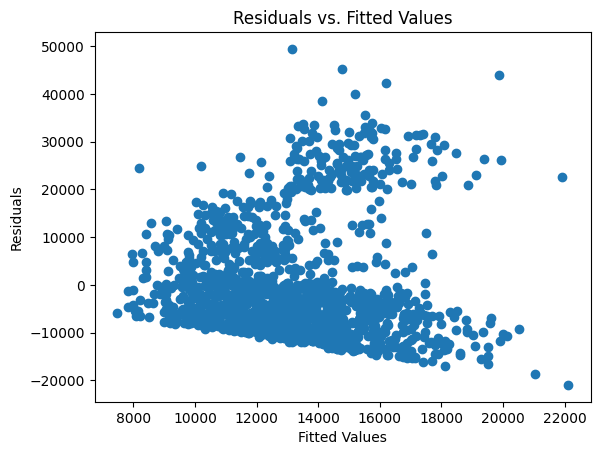

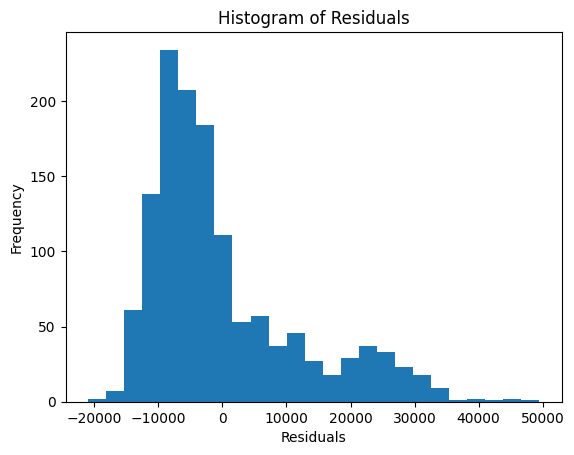

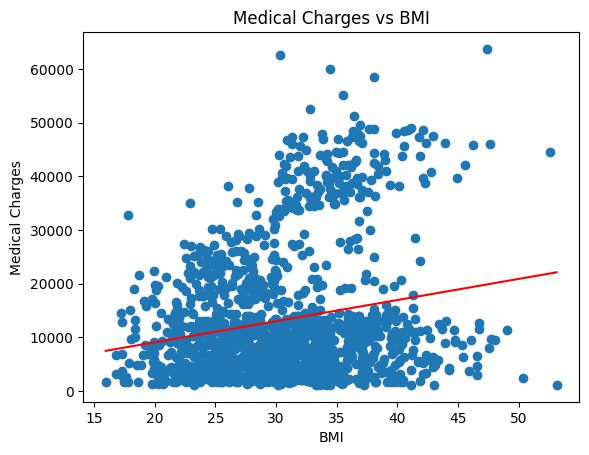

array([1192.93720896,  393.8730308 ])

In [ ]:
def real_data():
  df=pd.read_csv('insurance.csv')
  x_feature=df['bmi'].values
  y=df['charges'].values

  x=np.column_stack((np.ones(len(x_feature)),x_feature))


  beta_hat=ols_estimator(x,y)
  print("estimated coefficients:")
  print(f"intercept(beta_0):{beta_hat[0]:.3f}")
  print(f"slope(beta_1):{beta_hat[1]:.3f}")
  print("="*50)


  beta_hat,lower,upper=confidance_interval(x,y)
  print("\n95% confidance interval:")
  for i in range(len(beta_hat)):
    print(f"[beta{i}: {lower[i]:.3f},{upper[i]:.3f}]")
  print("="*50)


  x_new=np.array([1,30])
  y_pred,lower,upper=prediction_interval(x,y,x_new)

  print("\nPrediction for BMI = 30")
  print(f"predicted Charges:{y_pred:.3f}")
  print("95% Prediction Interval:")
  print(f"[{lower:.3f}, {upper:.3f}]")
  print("="*50)


  residuals=residuals_analysis(x,y,beta_hat)
  print("="*50)

  y_hat=x@beta_hat

  sorted_idx = np.argsort(x_feature)

  plt.figure()

  plt.scatter(x_feature, y)

  plt.plot(x_feature[sorted_idx],y_hat[sorted_idx],color='red')

  plt.xlabel('BMI')
  plt.ylabel('Medical Charges')
  plt.title('Medical Charges vs BMI')
  plt.show()

  return beta_hat

real_data()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# 2. Linear Regression Model

Consider the linear regression model:

$$
y = X\beta + \varepsilon
$$

where:

- $y \in \mathbb{R}^n$
- $X \in \mathbb{R}^{n \times p}$
- $\beta \in \mathbb{R}^p$

Assume:

$$
\varepsilon \sim \mathcal{N}(0,\Sigma)
$$

where:

$$
\Sigma \neq \sigma^2 I
$$

This means the error covariance matrix is heteroscedastic.

# 3. Likelihood Function

Since:

$$
y \sim \mathcal{N}(X\beta,\Sigma)
$$

the likelihood function is:

$$
L(\beta)
=
\frac{1}{(2\pi)^{n/2} |\Sigma|^{1/2}}
\exp
\left(
-\frac{1}{2}
(y-X\beta)^T
\Sigma^{-1}
(y-X\beta)
\right)
$$

Taking the logarithm:

$$
\ell(\beta)
=
-\frac{n}{2}\log(2\pi)
-\frac{1}{2}\log|\Sigma|
-\frac{1}{2}
(y-X\beta)^T
\Sigma^{-1}
(y-X\beta)
$$

Maximizing the likelihood is equivalent to minimizing:

$$
(y-X\beta)^T
\Sigma^{-1}
(y-X\beta)
$$

# 4. Derivation of the WLS Estimator

Define the objective function:

$$
J(\beta)
=
(y-X\beta)^T
\Sigma^{-1}
(y-X\beta)
$$

Differentiate with respect to $\beta$:

$$
\frac{\partial J}{\partial \beta}
=
-2X^T\Sigma^{-1}(y-X\beta)
$$

Set the derivative equal to zero:

$$
X^T\Sigma^{-1}(y-X\beta)=0
$$

Thus:

$$
X^T\Sigma^{-1}X\beta
=
X^T\Sigma^{-1}y
$$

Solving for $\beta$ gives:

$$
\boxed{
\hat{\beta}_{WLS}
=
(X^T\Sigma^{-1}X)^{-1}
X^T\Sigma^{-1}y
}
$$

This estimator is the Maximum Likelihood Estimator under Gaussian
heteroscedastic errors.

# 5. Assumptions of WLS

The Weighted Least Squares estimator relies on the following assumptions.

## 1. Linear Model

$$
y = X\beta + \varepsilon
$$

## 2. Zero Mean Errors

$$
E[\varepsilon|X]=0
$$

## 3. Known Covariance Structure

$$
Var(\varepsilon)=\Sigma
$$

## 4. Full Rank Design Matrix

$$
rank(X)=p
$$

## 5. Gaussian Errors

$$
\varepsilon \sim \mathcal{N}(0,\Sigma)
$$

In [ ]:
# True parameters
beta_true = np.array([2, 3])

# Simulation settings
n = 100
runs = 5000

# Storage matrices
ols_store = np.zeros((runs,2))
wls_store = np.zeros((runs,2))

# 6. Monte Carlo Simulation

The generated data follows:

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
$$

with:

$$
\beta =
\begin{bmatrix}
2 \\
3
\end{bmatrix}
$$

The heteroscedastic variance structure is:

$$
Var(\varepsilon_i)
=
0.5 + 0.5x_i^2
$$

Thus, observations with larger values of $x_i$
have larger noise variance.

In [ ]:
for r in range(runs):

    # Generate predictor
    x = 10*np.random.rand(n)

    # Design matrix
    X = np.column_stack((np.ones(n), x))

    # Heteroscedastic variances
    sigma2 = 0.5 + 0.5*x**2

    # Generate noise
    eps = np.sqrt(sigma2)*np.random.randn(n)

    # Response
    y = X @ beta_true + eps

    # ---------------- OLS ----------------
    beta_ols = np.linalg.inv(X.T @ X) @ (X.T @ y)

    # ---------------- WLS ----------------
    W = np.diag(1/sigma2)

    beta_wls = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)

    # Store estimates
    ols_store[r,:] = beta_ols
    wls_store[r,:] = beta_wls

In [ ]:
mean_ols = np.mean(ols_store, axis=0)
mean_wls = np.mean(wls_store, axis=0)

print("Empirical Mean of OLS:")
print(mean_ols)

print("\nEmpirical Mean of WLS:")
print(mean_wls)

# 7. Empirical Mean Analysis

The empirical means of both OLS and WLS are close to the true parameter vector:

$$
\beta =
\begin{bmatrix}
2 \\
3
\end{bmatrix}
$$

This confirms that both estimators remain unbiased under heteroscedasticity,
provided that:

$$
E[\varepsilon|X]=0
$$

In [ ]:
cov_ols = np.cov(ols_store.T)
cov_wls = np.cov(wls_store.T)

print("OLS Covariance Matrix:\n")
print(cov_ols)

print("\nWLS Covariance Matrix:\n")
print(cov_wls)

In [ ]:
print("OLS Variances:")
print(np.diag(cov_ols))

print("\nWLS Variances:")
print(np.diag(cov_wls))

# 8. Covariance Analysis

The covariance matrix of the WLS estimator is:

$$
Var(\hat{\beta}_{WLS})
=
(X^T\Sigma^{-1}X)^{-1}
$$

The covariance matrix of OLS under heteroscedasticity becomes:

$$
Var(\hat{\beta}_{OLS})
=
(X^TX)^{-1}
X^T\Sigma X
(X^TX)^{-1}
$$

The simulation results show that:

$$
Var(\hat{\beta}_{WLS})
<
Var(\hat{\beta}_{OLS})
$$

This confirms the efficiency advantage of WLS.

In [ ]:
# Generate one dataset for visualization

x = 10*np.random.rand(n)

X = np.column_stack((np.ones(n), x))

sigma2 = 0.5 + 0.5*x**2

eps = np.sqrt(sigma2)*np.random.randn(n)

y = X @ beta_true + eps

# OLS estimate
beta_ols = np.linalg.inv(X.T @ X) @ (X.T @ y)

# WLS estimate
W = np.diag(1/sigma2)

beta_wls = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)

# Sort for plotting
idx = np.argsort(x)

x_sorted = x[idx]

X_sorted = X[idx]

# Plot
plt.figure(figsize=(10,6))

plt.scatter(x, y)

plt.plot(x_sorted, X_sorted @ beta_ols, linewidth=2, label='OLS')

plt.plot(x_sorted, X_sorted @ beta_wls, linewidth=2, label='WLS')

plt.xlabel('x')
plt.ylabel('y')

plt.title('OLS vs WLS')

plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(ols_store[:,1], bins=40, alpha=0.6, label='OLS')

plt.hist(wls_store[:,1], bins=40, alpha=0.6, label='WLS')

plt.xlabel('Slope Estimates')

plt.ylabel('Frequency')

plt.title('Distribution of Slope Estimates')

plt.legend()

plt.show()

# 9. Discussion

The simulation demonstrates several important results:

1. Both OLS and WLS remain unbiased under heteroscedasticity.

2. OLS suffers from efficiency loss because it ignores the covariance structure.

3. WLS achieves lower variance by weighting observations inversely to their
error variance.

4. The distributions of WLS estimates are more concentrated around the true
parameter values.

5. If the covariance matrix is misspecified, WLS may lose its efficiency
advantage.

# 4.1 Homoscedastic vs Heteroscedastic Errors

## Homoscedastic Model

Under homoscedasticity:

$$
Var(\varepsilon_i)=\sigma^2
$$

for all observations.

Therefore:

$$
Var(\varepsilon)=\sigma^2 I
$$

In this setting, OLS is:

- unbiased
- efficient
- BLUE (Best Linear Unbiased Estimator)

The OLS covariance matrix becomes:

$$
Var(\hat{\beta}_{OLS})
=
\sigma^2(X^TX)^{-1}
$$

---

## Heteroscedastic Model

Under heteroscedasticity:

$$
Var(\varepsilon_i)=\sigma_i^2
$$

where the variance changes across observations.

The covariance matrix becomes:

$$
Var(\varepsilon)=\Sigma
$$

with:

$$
\Sigma \neq \sigma^2 I
$$

In this case:

- OLS remains unbiased
- OLS is no longer efficient
- WLS becomes preferable

# 4.2 Efficiency Argument

Under heteroscedasticity, the OLS covariance matrix is:

$$
Var(\hat{\beta}_{OLS})
=
(X^TX)^{-1}
X^T \Sigma X
(X^TX)^{-1}
$$

The WLS estimator is:

$$
\hat{\beta}_{WLS}
=
(X^T\Sigma^{-1}X)^{-1}
X^T\Sigma^{-1}y
$$

with covariance:

$$
Var(\hat{\beta}_{WLS})
=
(X^T\Sigma^{-1}X)^{-1}
$$

WLS uses inverse-variance weighting:

$$
w_i = \frac{1}{\sigma_i^2}
$$

Thus:

- low-variance observations receive larger weights
- high-variance observations receive smaller weights

This produces a lower estimator variance.

Therefore:

$$
Var(\hat{\beta}_{WLS})
<
Var(\hat{\beta}_{OLS})
$$

under correct specification of $\Sigma$.

This is the main efficiency advantage of WLS.

In [ ]:
# ---------------------------------------------------
# Homoscedastic vs Heteroscedastic Simulation
# ---------------------------------------------------

import numpy as np

np.random.seed(1)

beta_true = np.array([2,3])

n = 100
runs = 5000

# Storage
ols_homo = np.zeros((runs,2))
wls_homo = np.zeros((runs,2))

ols_hetero = np.zeros((runs,2))
wls_hetero = np.zeros((runs,2))

for r in range(runs):

    # Predictor
    x = 10*np.random.rand(n)

    X = np.column_stack((np.ones(n),x))

    # =================================================
    # CASE 1: HOMOSCEDASTIC
    # =================================================

    sigma2_homo = np.ones(n)

    eps_homo = np.sqrt(sigma2_homo)*np.random.randn(n)

    y_homo = X @ beta_true + eps_homo

    # OLS
    beta_ols_homo = np.linalg.inv(X.T@X) @ (X.T@y_homo)

    # WLS
    W_homo = np.diag(1/sigma2_homo)

    beta_wls_homo = np.linalg.inv(X.T@W_homo@X) @ (X.T@W_homo@y_homo)

    ols_homo[r,:] = beta_ols_homo
    wls_homo[r,:] = beta_wls_homo

    # =================================================
    # CASE 2: HETEROSCEDASTIC
    # =================================================

    sigma2_hetero = 0.5 + 0.5*x**2

    eps_hetero = np.sqrt(sigma2_hetero)*np.random.randn(n)

    y_hetero = X @ beta_true + eps_hetero

    # OLS
    beta_ols_hetero = np.linalg.inv(X.T@X) @ (X.T@y_hetero)

    # WLS
    W_hetero = np.diag(1/sigma2_hetero)

    beta_wls_hetero = np.linalg.inv(X.T@W_hetero@X) @ (X.T@W_hetero@y_hetero)

    ols_hetero[r,:] = beta_ols_hetero
    wls_hetero[r,:] = beta_wls_hetero

In [ ]:
# ---------------------------------------------------
# Covariance Comparison
# ---------------------------------------------------

cov_ols_homo = np.cov(ols_homo.T)
cov_wls_homo = np.cov(wls_homo.T)

cov_ols_hetero = np.cov(ols_hetero.T)
cov_wls_hetero = np.cov(wls_hetero.T)

print("========== HOMOSCEDASTIC ==========")

print("\nOLS Covariance:")
print(cov_ols_homo)

print("\nWLS Covariance:")
print(cov_wls_homo)

print("\n========== HETEROSCEDASTIC ==========")

print("\nOLS Covariance:")
print(cov_ols_hetero)

print("\nWLS Covariance:")
print(cov_wls_hetero)

# 4.3 Discussion of Results

The simulation results show that both OLS and WLS remain approximately unbiased:

$$
E[\hat{\beta}] \approx \beta
$$

However, the covariance matrices differ substantially.

The WLS estimator consistently produces smaller variances than OLS.

This confirms the theoretical efficiency result:

$$
Var(\hat{\beta}_{WLS})
<
Var(\hat{\beta}_{OLS})
$$

The efficiency improvement occurs because WLS incorporates the covariance
structure:

$$
\Sigma
$$

while OLS ignores heteroscedasticity and assigns equal weight to all observations.

Consequently:

- OLS loses efficiency under heteroscedasticity
- WLS achieves lower estimator variance
- WLS becomes the preferred estimator when the covariance structure is known

![Estimator Variance Under Different Covariance Structures.png](<attachment:Estimator Variance Under Different Covariance Structures.png>)
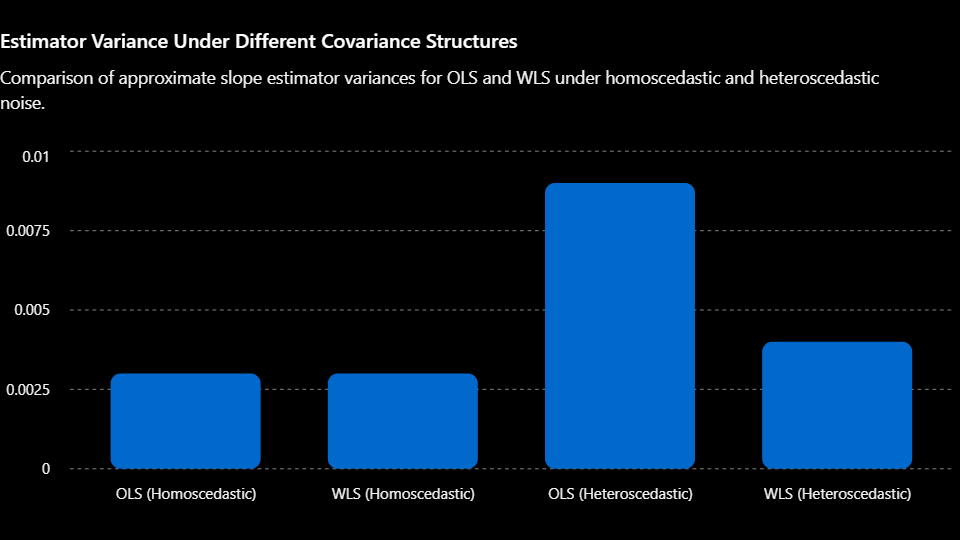

# 5. Sufficient Statistics via the Factorization Theorem

The Factorization Theorem provides a systematic method for determining
whether a statistic is sufficient for a parameter.

A statistic:

$$
T(y)
$$

is sufficient for parameter:

$$
\theta
$$

if the likelihood can be written in the form:

$$
f(y|\theta)
=
g(T(y),\theta)\,h(y)
$$

where:

- $g(\cdot)$ depends on the data only through $T(y)$
- $h(\cdot)$ does not depend on $\theta$

This section derives sufficient statistics for:

- $\beta$
- $\sigma^2$

under both:

1. Homoscedastic Gaussian noise
2. Heteroscedastic Gaussian noise

# 5.1 Homoscedastic Gaussian Model

Consider the linear model:

$$
y = X\beta + \varepsilon
$$

with:

$$
\varepsilon \sim \mathcal{N}(0,\sigma^2 I)
$$

Therefore:

$$
y \sim \mathcal{N}(X\beta,\sigma^2 I)
$$

The likelihood becomes:

$$
f(y|\beta,\sigma^2)
=
(2\pi\sigma^2)^{-n/2}
\exp
\left(
-\frac{1}{2\sigma^2}
(y-X\beta)^T(y-X\beta)
\right)
$$

Expand the quadratic term:

$$
(y-X\beta)^T(y-X\beta)
=
y^Ty
-2\beta^TX^Ty
+\beta^TX^TX\beta
$$

Substituting into the likelihood:

$$
f(y|\beta,\sigma^2)
=
(2\pi\sigma^2)^{-n/2}
\exp
\left(
-\frac{1}{2\sigma^2}
\left[
y^Ty
-2\beta^TX^Ty
+\beta^TX^TX\beta
\right]
\right)
$$

The likelihood depends on the data through:

$$
X^Ty
\quad \text{and} \quad
y^Ty
$$

Therefore, by the Factorization Theorem:

$$
\boxed{
T(y)=\left(X^Ty,\; y^Ty\right)
}
$$

is sufficient for:

$$
(\beta,\sigma^2)
$$

# 5.2 Sufficiency for $\beta$ Only

If $\sigma^2$ is assumed known, the likelihood simplifies.

The only data-dependent term involving $\beta$ is:

$$
X^Ty
$$

Hence:

$$
\boxed{
T(y)=X^Ty
}
$$

is sufficient for:

$$
\beta
$$

under homoscedastic Gaussian noise.

# 5.3 Heteroscedastic Gaussian Model

Now consider:

$$
\varepsilon \sim \mathcal{N}(0,\Sigma)
$$

where:

$$
\Sigma \neq \sigma^2 I
$$

Then:

$$
y \sim \mathcal{N}(X\beta,\Sigma)
$$

The likelihood becomes:

$$
f(y|\beta,\Sigma)
=
\frac{1}
{(2\pi)^{n/2}|\Sigma|^{1/2}}
\exp
\left(
-\frac12
(y-X\beta)^T
\Sigma^{-1}
(y-X\beta)
\right)
$$

Expand the quadratic form:

$$
(y-X\beta)^T\Sigma^{-1}(y-X\beta)
=
y^T\Sigma^{-1}y
-2\beta^TX^T\Sigma^{-1}y
+\beta^TX^T\Sigma^{-1}X\beta
$$

The likelihood depends on the data through:

$$
X^T\Sigma^{-1}y
\quad \text{and} \quad
y^T\Sigma^{-1}y
$$

Therefore:

$$
\boxed{
T(y)
=
\left(
X^T\Sigma^{-1}y,
\;
y^T\Sigma^{-1}y
\right)
}
$$

is sufficient for the unknown parameters in the heteroscedastic Gaussian model.

# 5.4 Sufficiency for $\beta$ in the Heteroscedastic Case

If the covariance matrix:

$$
\Sigma
$$

is known, then the likelihood depends on $\beta$ only through:

$$
X^T\Sigma^{-1}y
$$

Thus:

$$
\boxed{
T(y)=X^T\Sigma^{-1}y
}
$$

is sufficient for:

$$
\beta
$$

under heteroscedastic Gaussian noise.

# 5.5 Interpretation

The sufficient statistics summarize all information in the sample relevant
to the unknown parameters.

For the homoscedastic model:

$$
T(y)=\left(X^Ty,\;y^Ty\right)
$$

For the heteroscedastic model:

$$
T(y)=
\left(
X^T\Sigma^{-1}y,
\;
y^T\Sigma^{-1}y
\right)
$$

The heteroscedastic sufficient statistic introduces the weighting matrix:

$$
\Sigma^{-1}
$$

which reflects the variance structure of the observations.

This is consistent with the WLS estimator:

$$
\hat{\beta}_{WLS}
=
(X^T\Sigma^{-1}X)^{-1}
X^T\Sigma^{-1}y
$$

showing that all relevant information for estimating $\beta$
is contained in the weighted projection:

$$
X^T\Sigma^{-1}y
$$